In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["JAX_PLATFORMS"] = "cpu"   # set to gpu if you have a beefy one
os.environ["JAX_ENABLE_X64"] = "True"

import lusee as lu
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import jax
from astropy.coordinates import SkyCoord, GeocentricMeanEcliptic
from astropy import units as u

print("jax devices:", jax.devices())


The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


jax devices: [CpuDevice(id=0)]


In [2]:
def _ecliptic_to_eq_gal(lon_deg, lat_deg):
    """Ecliptic (lon, lat) -> ICRS (ra, dec) and galactic (l, b), all in degrees."""
    c = SkyCoord(lon=lon_deg*u.deg, lat=lat_deg*u.deg, frame=GeocentricMeanEcliptic)
    return c.icrs.ra.deg, c.icrs.dec.deg, c.galactic.l.deg, c.galactic.b.deg

ecl_lon_deg, ecl_lat_deg = 45.0, 0.0
ra_deg, dec_deg, l_deg, b_deg = _ecliptic_to_eq_gal(ecl_lon_deg, ecl_lat_deg)
print(f"ra={ra_deg:.3f} dec={dec_deg:.3f}  l={l_deg:.3f} b={b_deg:.3f}")


ra=42.533 dec=16.335  l=159.929 b=-37.866


In [3]:
time_start = "2025-03-01 00:00:00"
time_end = "2025-03-29 00:00:00"  # 28 days later
deltaT_sec = 7200.0  # 2 hours
obs = lu.Observation(
    f"{time_start} to {time_end}",
    deltaT_sec=deltaT_sec,
    lun_lat_deg=0.0,
    lun_long_deg=0.0,
)

In [4]:
## first sanity check, it the source actually reaching our zenith.a
alt,az = obs.get_track_ra_dec(ra_deg, dec_deg)


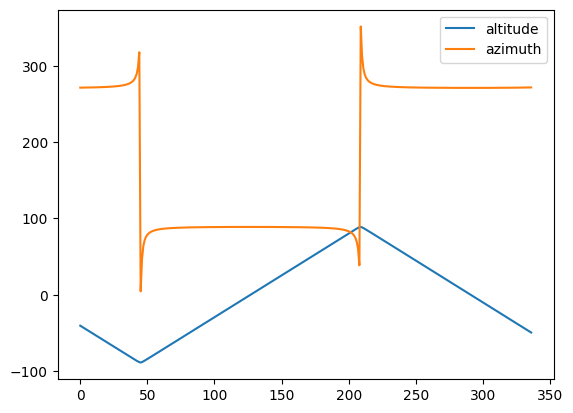

In [5]:
plt.plot(alt/np.pi*180, label="altitude")
plt.plot(az/np.pi*180, label="azimuth")
plt.legend()

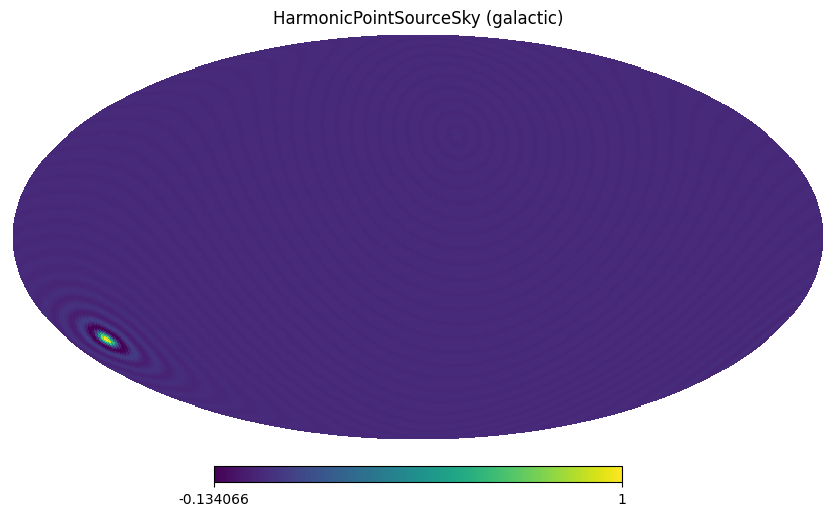

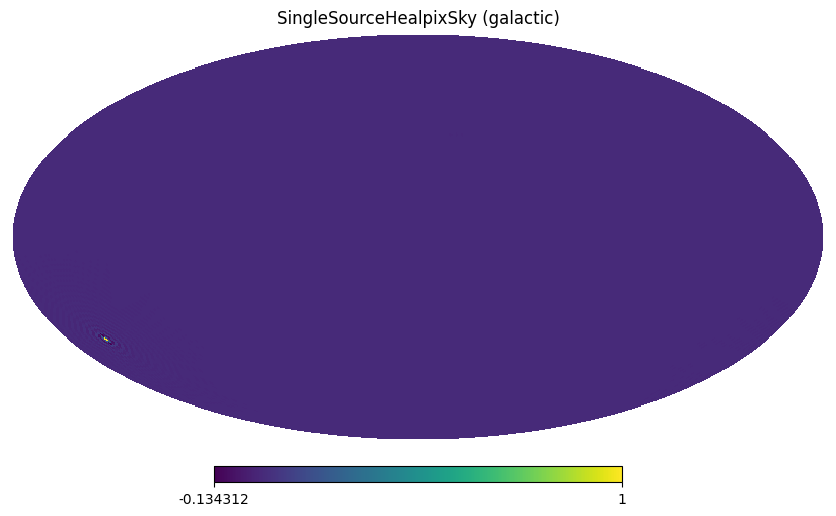

In [6]:
# Visualize point-source sky models. Use galactic-frame inputs since both
# simulators expect galactic alms (CroSimulator does galactic->MEPA internally,
# DefaultSimulator does galactic->topo per timestep).
#
# Note: HarmonicPointSourceSky uses jax.scipy.special.sph_harm_y which
# allocates an O(nalm * (lmax+1)^2) internal table — keep lmax modest for viz.
nside_viz = 64
lmax_viz = 64

sky_h = lu.sky.HarmonicPointSourceSky(lmax=lmax_viz, freq=[25.0],
                                      l_deg=l_deg, b_deg=b_deg)
sky_p = lu.sky.SingleSourceHealpixSky(Nside=nside_viz, freq=[25.0],
                                      l_deg=l_deg, b_deg=b_deg)

alm_h = np.asarray(sky_h.get_alm(0, freq=[25.0])[0])
alm_p = np.asarray(sky_p.get_alm(0, freq=[25.0])[0])

mp_h = hp.alm2map(alm_h, nside=nside_viz)
mp_h /= mp_h.max()
hp.mollview(mp_h, title="HarmonicPointSourceSky (galactic)")

mp_p = hp.alm2map(alm_p, nside=nside_viz)
mp_p /= mp_p.max()
hp.mollview(mp_p, title="SingleSourceHealpixSky (galactic)")


In [7]:
# Run both simulators with a Gaussian beam at zenith and a single point source.
# Both engines expect galactic-frame sky alms; we use SingleSourceHealpixSky in
# galactic frame so no adapter is needed.
nside = 32
lmax = 3 * nside - 1
sigma_deg = 20.0
Tground = 0.0

beam = lu.BeamGauss(
    alt_deg=90.0,
    az_deg=0.0,
    sigma_deg=sigma_deg,
    one_over_freq_scaling=False,
    id="b0",
)
freq = np.asarray(beam.freq)[::5]    # subset of beam frequency grid

sky = lu.sky.SingleSourceHealpixSky(
    Nside=nside,
    freq=freq,
    l_deg=l_deg,
    b_deg=b_deg,
)

# DefaultSimulator is numpy-facing; wrap the jax-backed beam/sky.
np_sky  = lu.NpWrapper(sky)
np_beam = lu.NpWrapper(beam)

times = obs.times

def_sim = lu.DefaultSimulator(
    obs, [np_beam], np_sky,
    Tground=Tground,
    combinations=[(0, 0)],
    freq=freq,
    lmax=lmax,
)
def_sim.simulate(times=times)

if lu.CroSimulator is None:
    raise RuntimeError("CroSimulator unavailable; install croissant + s2fft.")
cro_sim = lu.CroSimulator(
    obs, [beam], sky,
    Tground=Tground,
    combinations=[(0, 0)],
    freq=freq,
    lmax=lmax,
)
cro_sim.simulate(times=times)

print("default result shape:", def_sim.result.shape,
      " cro result shape:", cro_sim.result.shape)


  intializing beam combination b0 x b0 ...
Getting pole transformations...
Getting horizon transformations...
0.0% done ...
29.673590504451035% done ...
59.34718100890207% done ...
89.02077151335311% done ...
  intializing beam combination b0 x b0 ...
default result shape: (337, 1, 10)  cro result shape: (337, 1, 10)


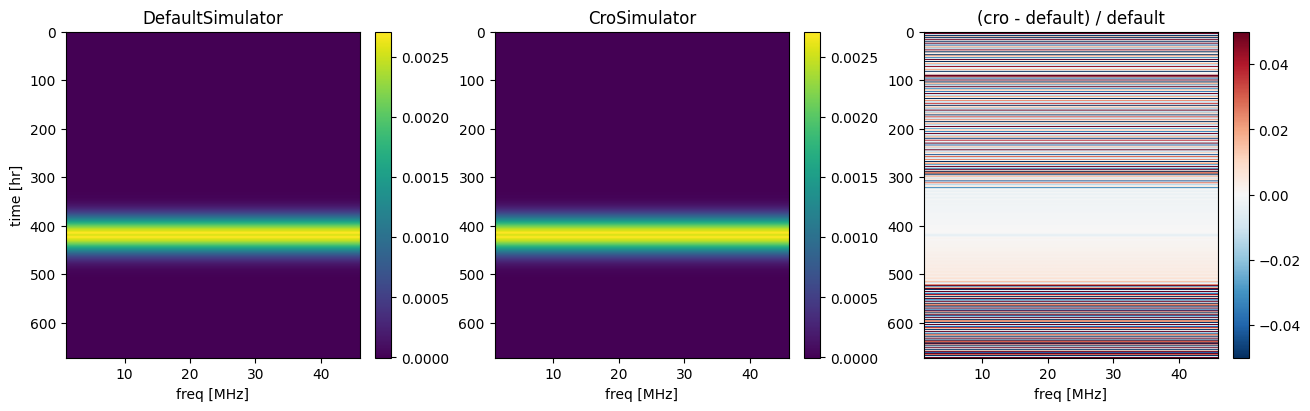

||cro - default|| / ||default|| = 1.528e-03


In [8]:
# Compare the two waterfalls (combo 0 = autocorr).
out_def = np.asarray(def_sim.result)[:, 0, :]
out_cro = np.asarray(cro_sim.result)[:, 0, :]

jd = np.array([float(t.jd) for t in times])
t_hours = (jd - jd[0]) * 24.0
extent = [float(freq[0]), float(freq[-1]), float(t_hours[-1]), float(t_hours[0])]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
im0 = axes[0].imshow(out_def, aspect="auto", extent=extent)
axes[0].set_title("DefaultSimulator")
axes[0].set_xlabel("freq [MHz]")
axes[0].set_ylabel("time [hr]")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(out_cro, aspect="auto", extent=extent)
axes[1].set_title("CroSimulator")
axes[1].set_xlabel("freq [MHz]")
fig.colorbar(im1, ax=axes[1])

denom = np.maximum(np.abs(out_def), 1e-30)
rel = (out_cro - out_def) / denom
im2 = axes[2].imshow(rel, aspect="auto", extent=extent, cmap="RdBu_r",
                     vmin=-0.05, vmax=0.05)
axes[2].set_title("(cro - default) / default")
axes[2].set_xlabel("freq [MHz]")
fig.colorbar(im2, ax=axes[2])
plt.show()

rel_norm = np.linalg.norm(out_cro - out_def) / np.linalg.norm(out_def)
print(f"||cro - default|| / ||default|| = {rel_norm:.3e}")


In [9]:
B = lu.BeamGauss(
    alt_deg=60.0,
    az_deg=45.0,
    sigma_deg=10.0,
    one_over_freq_scaling=False,
)

In [10]:
a = B.get_healpix_alm(lmax=64)

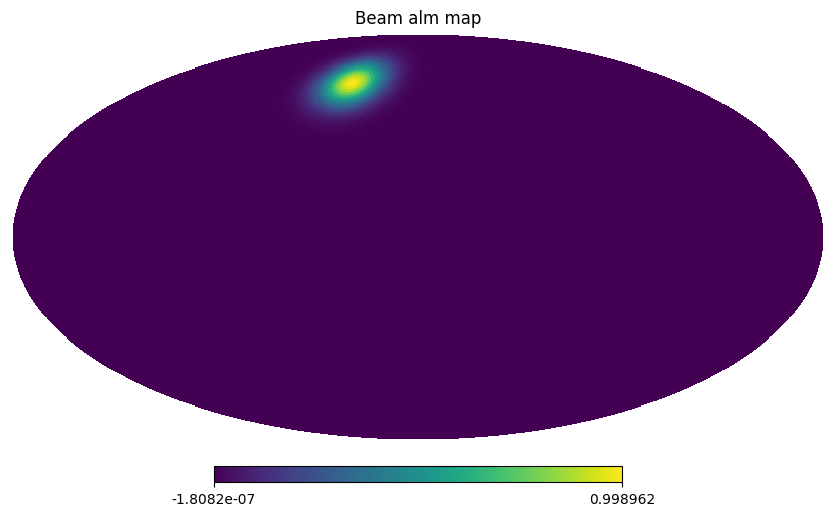

In [11]:
hp.mollview(hp.alm2map(np.asarray(a[1]), nside=64), title="Beam alm map")
